In [280]:
import numpy as np

import xgboost as xgb
import seaborn as sns
from matplotlib import rc
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

from syntherela.metadata import Metadata
from syntherela.visualisations.utils import prettyify_feature_name
from syntherela.metrics.multi_table.detection import AggregationDetection
from syntherela.data import load_tables

sns.set_theme(style="white")
rc("font", **{"family": "serif", "serif": ["Times"], "size": 30})
rc("text", usetex=True)

In [162]:
dataset_name = "Berka_subsampled"
method = "CLAVADDPM"

metadata = Metadata().load_from_json(f"data/original/{dataset_name}/metadata.json")

tables = load_tables(f"data/original/{dataset_name}/", metadata)
tables_synthetic = load_tables(
    f"data/synthetic/{dataset_name}/{method}/1/sample1", metadata
)

<Axes: xlabel='Feature importance'>

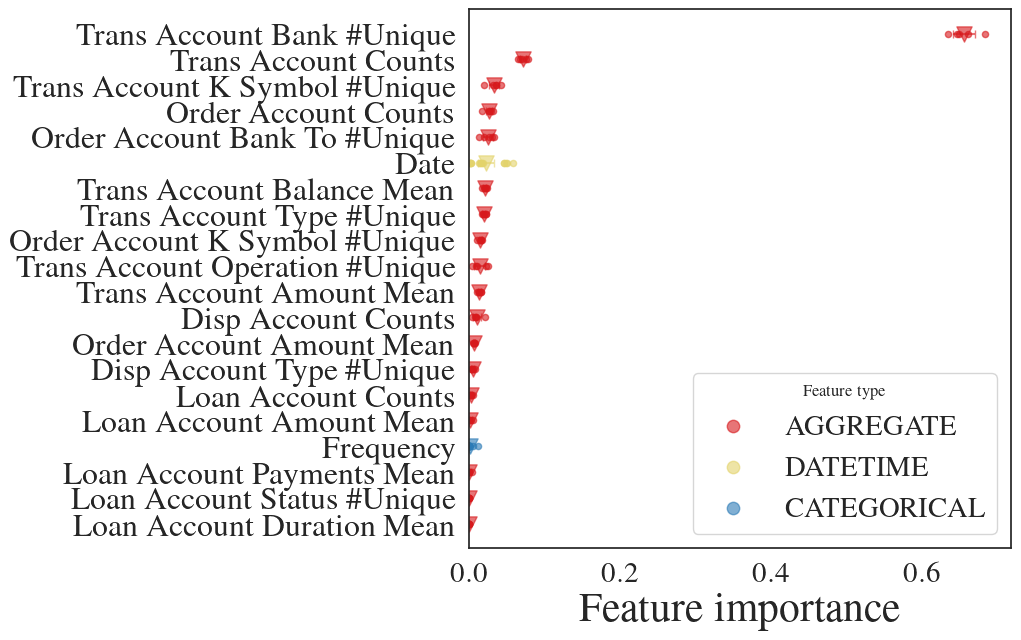

In [163]:
# Compute the metric
xgb_cls = xgb.XGBClassifier
xgb_args = {
    "seed": 0,
    "importance_type": "gain",
}

metric = AggregationDetection(
    classifier_cls=xgb_cls, classifier_args=xgb_args, random_state=42
)

for table in tables.keys():
    tables_synthetic[table] = tables_synthetic[table][tables[table].columns]


metric.run(tables, tables_synthetic, metadata=metadata, target_table="account")

# Plot the feature importance

fig, ax = plt.subplots(figsize=(7, 7))
metric.plot_feature_importance(
    metadata, ax=ax, combine_categorical=True, combine_datetime=True
)
# plt.savefig(
#     f"results/figures/figure4{figure_name}.png", bbox_inches="tight", dpi=600
# )

In [164]:
feature_importance = metric.feature_importance(combine_categorical=False)

# pair = ['features_Store_MarkDown3_mean', 'depts_Store_Dept_nunique'] # Walamrt
pair = ["trans_account_id_bank_nunique", "trans_account_id_counts"]
# feature_importance

In [165]:
# set colormap to coolwarm
cmap = sns.color_palette("coolwarm", as_cmap=True)

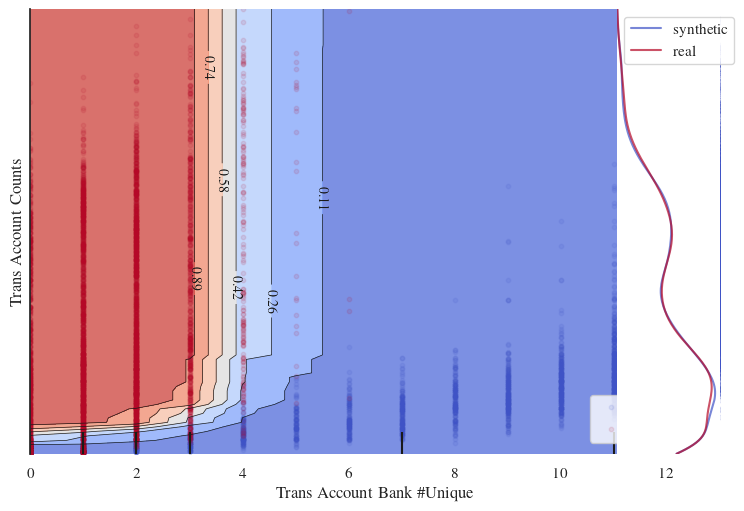

In [ ]:
color_real = "#b50827"
color_synthetic = "#3f53c6"

fig, ax = plt.subplots(figsize=(8, 6))


disp = PartialDependenceDisplay.from_estimator(
    metric.models[0],
    metric.X,
    [pair],
    response_method="predict_proba",
    contour_kw={"cmap": cmap},
    ax=ax,
    n_jobs=-1,
    percentiles=(0.0, 1.0),
)
ax = disp.axes_[0, 0]
ax.scatter(
    metric.X.loc[metric.y == 0, pair[0]],
    metric.X.loc[metric.y == 0, pair[1]],
    s=10,
    alpha=0.1,
    label="synthetic",
    color=color_synthetic,
)
ax.scatter(
    metric.X.loc[metric.y == 1, pair[0]],
    metric.X.loc[metric.y == 1, pair[1]],
    s=10,
    alpha=0.1,
    label="real",
    color=color_real,
)
ax.legend(bbox_to_anchor=(0.8, 0.15))


ax.set_xlabel(prettyify_feature_name(pair[0]))
ax.set_ylabel(prettyify_feature_name(pair[1]))

# Create a new axes for the marginal distribution on the right
ax_histy = fig.add_subplot(1, 2, 2, sharey=ax)

clip = (metric.X[pair[1]].min(), metric.X[pair[1]].max())
sns.kdeplot(
    y=metric.X.loc[metric.y == 0, pair[1]],
    ax=ax_histy,
    alpha=0.7,
    label="synthetic",
    color=color_synthetic,
    clip=clip,
)
sns.kdeplot(
    y=metric.X.loc[metric.y == 1, pair[1]],
    ax=ax_histy,
    alpha=0.7,
    label="real",
    color=color_real,
    clip=clip,
)

ax_histy.set_ylabel(None)
ax_histy.legend()
ax_histy.set_yticks([])  # Hide the y-ticks on the histogram axes
ax_histy.set_xticks([])  # Hide the x-ticks on the histogram axes
ax_histy.set_xlabel("")
# ax_histy.yaxis.set_label_position("right")
# ax_histy.set_ylabel('Account - Transaction Cardinality', rotation=270)

# disp.ax_.set_position([0.3, 0.1, 0.5, 0.8])  # [left, bottom, width, height] - changed width
# ax.set_position([0., 0., 0., 0.8])
ax_histy.set_position([0.0, 0.1, 0.15, 0.8])
ax_histy.grid(False)


# remove the top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax_histy.spines["top"].set_visible(False)
ax_histy.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax_histy.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax_histy.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

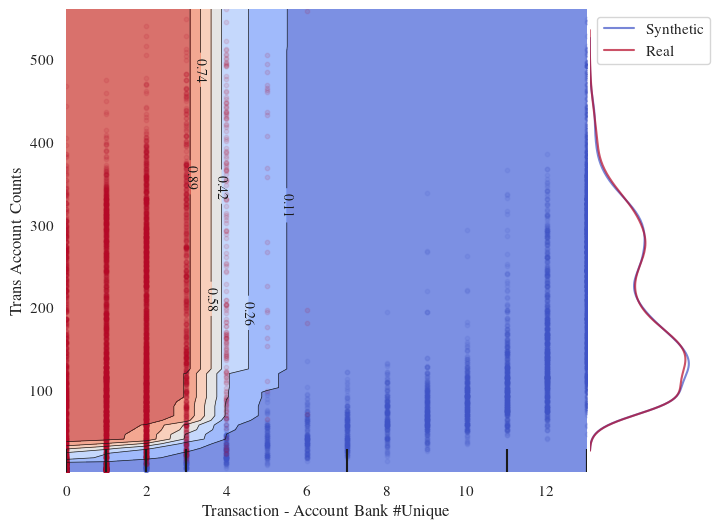

In [218]:
fig, (ax, ax_histy) = plt.subplots(
    1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [5, 1]}
)


disp = PartialDependenceDisplay.from_estimator(
    metric.models[0],
    metric.X,
    [pair],
    response_method="predict_proba",
    contour_kw={"cmap": cmap},
    ax=ax,
    n_jobs=-1,
    percentiles=(0.0, 1.0),
)
ax = disp.axes_[0, 0]
ax.scatter(
    metric.X.loc[metric.y == 0, pair[0]],
    metric.X.loc[metric.y == 0, pair[1]],
    s=10,
    alpha=0.1,
    label="synthetic",
    color=color_synthetic,
)
ax.scatter(
    metric.X.loc[metric.y == 1, pair[0]],
    metric.X.loc[metric.y == 1, pair[1]],
    s=10,
    alpha=0.1,
    label="real",
    color=color_real,
)
# ax.legend(loc='upper right')


ax.set_xlabel(prettyify_feature_name(pair[0].replace("trans", "transaction -")))
ax.set_ylabel(prettyify_feature_name(pair[1]).replace("trans", "transaction -"))


clip = None  # (metric.X[pair[1]].min(), metric.X[pair[1]].max())
sns.kdeplot(
    y=metric.X.loc[metric.y == 0, pair[1]],
    ax=ax_histy,
    alpha=0.7,
    label="Synthetic",
    color=color_synthetic,
    clip=clip,
    legend=False,
)
sns.kdeplot(
    y=metric.X.loc[metric.y == 1, pair[1]],
    ax=ax_histy,
    alpha=0.7,
    label="Real",
    color=color_real,
    clip=clip,
    legend=False,
)

ax_histy.set_ylabel(None)
ax_histy.legend()
ax_histy.set_yticks([])  # Hide the y-ticks on the histogram axes
ax_histy.set_xticks([])  # Hide the x-ticks on the histogram axes
ax_histy.set_xlabel("")


# Adjust the positions to prevent overlap.  Make the marginal plot narrower and move the PDP plot to the left
# ax.set_position([0.3, 0.1, 0.65, 0.8])  # [left, bottom, width, height]
# ax_histy.set_position([, 0.1, .2, 1.])


ax_histy.grid(False)


# remove the top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax_histy.spines["top"].set_visible(False)
ax_histy.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax_histy.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax_histy.spines["bottom"].set_visible(False)

# Reduce the space between the two subplots


plt.tight_layout()
plt.subplots_adjust(wspace=0.01)  # Adjust the width space between the two subplots
plt.show()

In [267]:
from syntherela.metrics.multi_table.trends import multi_table_trends

In [269]:
res_multi = multi_table_trends(tables, tables_synthetic, metadata)

Generating report ...

(1/1) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 150.12it/s]|
Column Pair Trends Score: 80.65%

Overall Score (Average): 80.65%

Generating report ...

(1/1) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 151.89it/s]|
Column Pair Trends Score: 81.79%

Overall Score (Average): 81.79%

Generating report ...

(1/1) Evaluating Column Pair Trends: |██████████| 253/253 [00:01<00:00, 152.67it/s]|
Column Pair Trends Score: 84.05%

Overall Score (Average): 84.05%

Generating report ...

(1/1) Evaluating Column Pair Trends: |██████████| 210/210 [00:01<00:00, 120.76it/s]|
Column Pair Trends Score: 81.87%

Overall Score (Average): 81.87%

Generating report ...

(1/1) Evaluating Column Pair Trends: |██████████| 300/300 [01:18<00:00,  3.84it/s]|
Column Pair Trends Score: 84.41%

Overall Score (Average): 84.41%

Generating report ...

(1/1) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 138.55it/s]|
Column Pair Trends

In [282]:
res_multi["cardinality"]

0.9558614203434512

In [281]:
relations = res_multi["hop_relation"][1]

values = []
for rel in relations:
    if "trans" in rel:
        print(rel, relations[rel])
        values.append(relations[rel])

print(np.mean(values))

account - trans : frequency balance 0.9742441461615932
account - trans : frequency amount 0.98778716144236
account - trans : frequency date 0.9838703814215105
account - trans : frequency bank 0.9896921099411083
account - trans : frequency operation 0.9895392440069692
account - trans : frequency k_symbol 0.9889482159699361
account - trans : frequency type 0.9880667924237374
account - trans : date balance 0.9895901235025749
account - trans : date amount 0.9977085555707177
account - trans : date date 0.912480016168661
account - trans : date bank 0.9064924022363408
account - trans : date operation 0.9066853824107369
account - trans : date k_symbol 0.9060063071800321
account - trans : date type 0.9067010550081549
0.9591294209603166
